# Preamble

## Imports & Path

In [1]:
%cd ..

/home/aru/Work/shome2023notebook


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, fisher_exact, MonteCarloMethod
from scipy.stats.contingency import association

In [3]:
sns.set_theme(
    context="talk",
    palette="colorblind",
    style="whitegrid",
)

## Data Loading & Prep


In [4]:
data = pd.read_csv("data/shome2023notebook/annotations.csv")
data.head()

,notebook,stmt,source,CALL,CGH,CKG,EC,Intent,Stage,Notes,Type
0,data/assert_notebooks/lepmik/meta-reinforcemen...,np.unique(env._s_hist[:-1][np.diff(env._s_hist...,GH,-1,-2.0,NaN,NaN,EXP,EVAL,RL context. Diagnostic to identify which state...,COMPUTE
1,data/assert_notebooks/dhuynh95/cryptotree/nbs/...,"(comparator.weight.data, comparator.bias.data)",GH,117,-2.0,NaN,NaN,EXP,EVAL,Check learned weights and bias of model.,INSPECT
2,data/assert_notebooks/nikohou/LoadLanguageMode...,assert dim % 2 == 0,GH,992,-2.0,NaN,NaN,VAL,MODEL,Defined inside `__init__` method of a neural n...,EQ
3,data/assert_notebooks/EricCousineau-TRI/repro/...,assert activated.ndim > 1,GH,1021,-2.0,NaN,NaN,VAL,MODEL,"Ensure activation tensor is a batch (2D), not ...",SHAPE
4,data/assert_notebooks/H-E-L-P/XID_plus/docs/bu...,"plt.plot(test_x, test_y, 'ro', alpha=0.5)",GH,614,-2.0,NaN,NaN,EXP,EVAL,Visually inspect actual vs. predictions of the...,INSPECT


## Helper Functions

In [5]:
def annot_count_with_percent(ax, orient="v") -> None:
    """Annotate each bar with count and percentage relative to hue size."""
    get_val = (lambda p: p.get_width()) if orient == "h" else (lambda p: p.get_height())
    for container in ax.containers:
        total = sum(get_val(p) for p in container)
        labels = [
            f"{int(get_val(p))} ({100 * get_val(p) / total:.1f}%)"
            for p in container
        ]
        ax.bar_label(container, labels=labels, fontsize=10.0)

In [6]:
def counts(row, col):
    freq = pd.crosstab(row, col)
    pct = pd.crosstab(row, col, normalize="index")
    return freq, pct

In [7]:
def pearson_residuals(observed, expected):
    """Calculate the Pearson residuals from expected frequencies."""
    residuals = (observed - expected) / np.sqrt(expected)

    return residuals

In [8]:
def chi2(observed_freq):
    statistic, pvalue, dof, expected_freq = chi2_contingency(observed_freq)

    if dof == 1:
        if (expected_freq < 5).any():
            print("WARNING: Some expected frequencies are less than 5. Chi-square approximation may be invalid.")
    else:
        total = expected_freq.size
        pct_less_than_5 = (expected_freq < 5).sum() / total
        if pct_less_than_5 > 0.20 or (expected_freq < 1).any():
            print("WARNING: More than 20% of expected frequencies are less than 5, or at least one is less than 1. Chi-square approximation may be invalid.")

    cramers_v = association(observed_freq, method="cramer", correction=True)
    residuals = pearson_residuals(observed_freq, expected_freq)

    print(f"statistic: {statistic}")
    print(f"pvalue: {pvalue}")
    print(f"dof: {dof}")
    print(f"cramer's v: {cramers_v}")
    print(f"expected_freq:\n{expected_freq}")
    print(f"residuals:\n{residuals}")

In [9]:
def fisher(observed_freq):
    rng = np.random.default_rng()
    method = MonteCarloMethod(rng=rng)
    statistic, pvalue = fisher_exact(observed_freq, method=method)
    cramers_v = association(observed_freq, method="cramer", correction=True)
    
    print(f"statistic: {statistic}")
    print(f"pvalue: {pvalue}")
    print(f"cramer's v: {cramers_v}")

# RQ1: Prevalence and Variation of Feedback Mechanisms

## Intent x Source

In [10]:
freq, pct = counts(data["source"], data["Intent"])

In [11]:
freq

Intent,EXP,VAL
source,,
GH,263,119
KG,429,4


In [12]:
pct

Intent,EXP,VAL
source,,
GH,0.688482,0.311518
KG,0.990762,0.009238


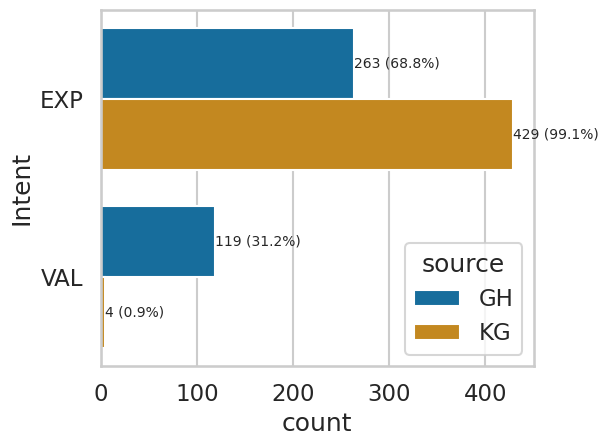

In [13]:
ax = sns.countplot(
    data=data,
    y='Intent',
    order=data["Intent"].value_counts().index,
    hue='source',
)
annot_count_with_percent(ax, orient='h')
ax.get_figure().tight_layout()
ax.get_figure().savefig("report/distribution-intent.pdf")

Are the two populations siginificantly different from one another?

In [14]:
chi2(freq)

statistic: 142.36709812111934
pvalue: 8.083770205966849e-33
dof: 1
cramer's v: 0.41795161918197365
expected_freq:
[[324.34846626  57.65153374]
 [367.65153374  65.34846626]]
residuals:
Intent       EXP       VAL
source                    
GH     -3.406417  8.079757
KG      3.199525 -7.589025


$pvalue < 0.001$ so we reject $H_0$. This means that there is a significant difference between the Intent of the statements from GH and KG.

## Type-EXP x Source

In [15]:
d = data[data["Intent"] == "EXP"]

In [16]:
freq, pct = counts(d["source"], d["Type"])
freq

Type,COMPUTE,INSPECT,STATS,STRUCT
source,,,,
GH,82,121,20,40
KG,103,182,58,86


In [17]:
pct

Type,COMPUTE,INSPECT,STATS,STRUCT
source,,,,
GH,0.311787,0.460076,0.076046,0.152091
KG,0.240093,0.424242,0.135198,0.200466


Are the populations significantly different? We apply $X^2$ test since the sample size is large.

In [18]:
chi2(freq)

statistic: 10.769711813259374
pvalue: 0.013038590514346938
dof: 3
cramer's v: 0.12475242426582903
expected_freq:
[[ 70.31069364 115.15751445  29.64450867  47.88728324]
 [114.68930636 187.84248555  48.35549133  78.11271676]]
residuals:
Type     COMPUTE   INSPECT     STATS    STRUCT
source                                        
GH      1.394049  0.544442 -1.771365 -1.139770
KG     -1.091509 -0.426286  1.386939  0.892414


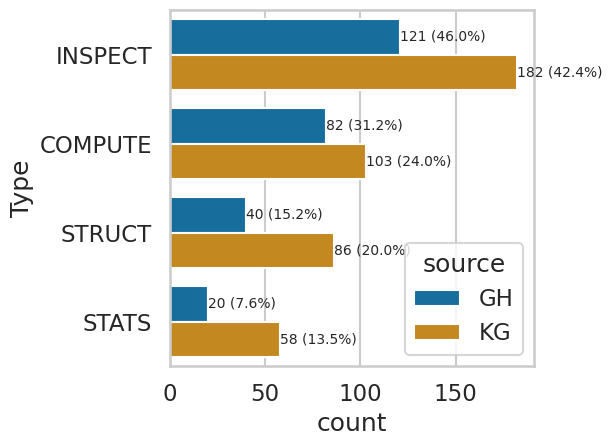

In [19]:
ax = sns.countplot(
    data=d,
    y="Type",
    order=d["Type"].value_counts().index,
    hue="source",
)
annot_count_with_percent(ax, orient='h')
ax.get_figure().tight_layout()
ax.get_figure().savefig("report/distribution-intent-exp.pdf")

## Type-VAL x Source

In [47]:
d = data[data["Intent"] == "VAL"]
d.shape

(123, 11)

In [48]:
freq, pct = counts(d["source"], d["Type"])
freq

Type,APPROX,BOOL,EQ,EXIST,SHAPE,TYPE
source,,,,,,
GH,8,18,34,6,47,6
KG,0,3,1,0,0,0


In [49]:
pct

Type,APPROX,BOOL,EQ,EXIST,SHAPE,TYPE
source,,,,,,
GH,0.067227,0.151261,0.285714,0.05042,0.394958,0.05042
KG,0.000000,0.750000,0.250000,0.00000,0.000000,0.00000


Are the populations significantly different? We apply $X^2$ test since the sample size is large.

In [50]:
chi2(freq)

statistic: 10.395198079231692
pvalue: 0.06478127860957235
dof: 5
cramer's v: 0.29071258232523906
expected_freq:
[[ 7.7398374  20.31707317 33.86178862  5.80487805 45.47154472  5.80487805]
 [ 0.2601626   0.68292683  1.13821138  0.19512195  1.52845528  0.19512195]]
residuals:
Type      APPROX      BOOL        EQ     EXIST     SHAPE      TYPE
source                                                            
GH      0.093514 -0.514055  0.023751  0.080986  0.226664  0.080986
KG     -0.510061  2.803836 -0.129548 -0.441726 -1.236307 -0.441726


Note that we do not have enough data for any statistical tests (not even Fisher). Thus for this section we provide a descriptive reporting.

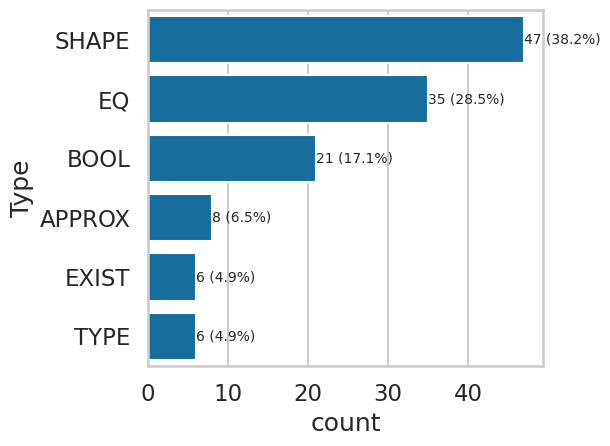

In [53]:
ax = sns.countplot(
    data=d,
    y="Type",
    order=d["Type"].value_counts().index,
    # hue="source",
)
annot_count_with_percent(ax, orient='h')
ax.get_figure().tight_layout()
ax.get_figure().savefig("report/distribution-intent-val.pdf")

# RQ2: Pipeline Stage Distribution of Validation Statements

## Stage x Source

In [25]:
freq, _ = counts(data["source"], data["Stage"])
freq

Stage,DATA,EVAL,FEAT,MODEL,PREP,TRAIN,UNC
source,,,,,,,
GH,71,94,49,40,76,50,2
KG,29,77,51,2,253,21,0


There are 2 statements where the stage was unclear (UNC). These are removed prior to the test.

In [26]:
d = data[data["Stage"] != "UNC"]

In [27]:
freq, pct = counts(d["source"], d["Stage"])
freq

Stage,DATA,EVAL,FEAT,MODEL,PREP,TRAIN
source,,,,,,
GH,71,94,49,40,76,50
KG,29,77,51,2,253,21


In [28]:
pct

Stage,DATA,EVAL,FEAT,MODEL,PREP,TRAIN
source,,,,,,
GH,0.186842,0.247368,0.128947,0.105263,0.200000,0.131579
KG,0.066975,0.177829,0.117783,0.004619,0.584296,0.048499


Are the two populations siginificantly different from one another?

In [29]:
chi2(freq)

statistic: 158.0375319815066
pvalue: 2.5927632872693826e-32
dof: 5
cramer's v: 0.4408946679404677
expected_freq:
[[ 46.7404674   79.92619926  46.7404674   19.63099631 153.77613776
   33.18573186]
 [ 53.2595326   91.07380074  53.2595326   22.36900369 175.22386224
   37.81426814]]
residuals:
Stage       DATA      EVAL      FEAT     MODEL      PREP     TRAIN
source                                                            
GH      3.548427  1.574225  0.330500  4.597255 -6.271940  2.918786
KG     -3.324174 -1.474737 -0.309614 -4.306718  5.875567 -2.734325


$pvalue < 0.001$ so we reject $H_0$. This means that there is a significant difference between the Intent of the statements from GH and KG.

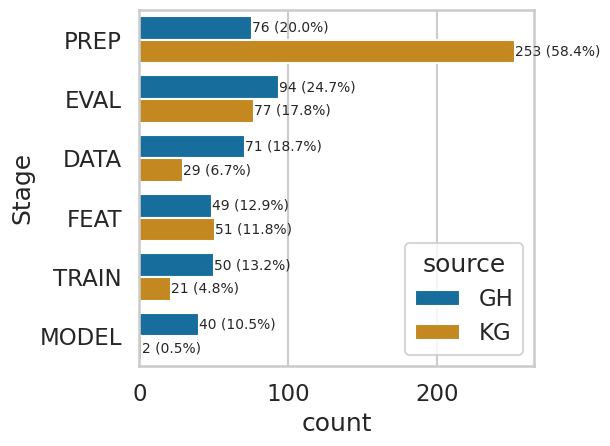

In [30]:
ax = sns.countplot(
    data=d,
    y='Stage',
    order=d["Stage"].value_counts().index,
    hue='source'
)
annot_count_with_percent(ax, orient="h")
ax.get_figure().tight_layout()
ax.get_figure().savefig("report/distribution-stage.pdf")

Can also use this to explain why GH has more assertions.

## Type-VAL x Stage

- We restrict this analysis only to GH.
- Interpretation of stage: how far into the lifecycle.
- As we move forward (maturity increase), are the assertion types changing and how?
- How would knowing this help? Why do we care what type of assertion is used in which stage?
- Would we change tools and how notebooks are designed based on this knowledge?
- Are there some types of assertions that are less recommended than others?

In [68]:
d = data[(data["source"] == "GH") & (data["Intent"] == "VAL") & (data["Stage"] != "UNC")]
d.shape

(117, 11)

In [69]:
freq, pct = counts(d["Type"], d["Stage"])
freq

Stage,DATA,EVAL,FEAT,MODEL,PREP,TRAIN
Type,,,,,,
APPROX,2,2,1,1,1,0
BOOL,2,4,2,1,6,3
EQ,4,2,7,8,7,5
EXIST,1,0,1,0,0,4
SHAPE,7,12,3,11,9,5
TYPE,1,2,0,3,0,0


In [70]:
pct

Stage,DATA,EVAL,FEAT,MODEL,PREP,TRAIN
Type,,,,,,
APPROX,0.285714,0.285714,0.142857,0.142857,0.142857,0.000000
BOOL,0.111111,0.222222,0.111111,0.055556,0.333333,0.166667
EQ,0.121212,0.060606,0.212121,0.242424,0.212121,0.151515
EXIST,0.166667,0.000000,0.166667,0.000000,0.000000,0.666667
SHAPE,0.148936,0.255319,0.063830,0.234043,0.191489,0.106383
TYPE,0.166667,0.333333,0.000000,0.500000,0.000000,0.000000


Are the two populations siginificantly different from one another?

In [71]:
chi2(freq)

statistic: 36.14656264643456
pvalue: 0.06940526227762633
dof: 25
cramer's v: 0.24857392457136612
expected_freq:
[[1.01709402 1.31623932 0.83760684 1.43589744 1.37606838 1.01709402]
 [2.61538462 3.38461538 2.15384615 3.69230769 3.53846154 2.61538462]
 [4.79487179 6.20512821 3.94871795 6.76923077 6.48717949 4.79487179]
 [0.87179487 1.12820513 0.71794872 1.23076923 1.17948718 0.87179487]
 [6.82905983 8.83760684 5.62393162 9.64102564 9.23931624 6.82905983]
 [0.87179487 1.12820513 0.71794872 1.23076923 1.17948718 0.87179487]]
residuals:
Stage       DATA      EVAL      FEAT     MODEL      PREP     TRAIN
Type                                                              
APPROX  0.974611  0.595987  0.177438 -0.363766 -0.320588 -1.008511
BOOL   -0.380521  0.334497 -0.104828 -1.401121  1.308577  0.237826
EQ     -0.363002 -1.688122  1.535516  0.473050  0.201343  0.093678
EXIST   0.137309 -1.062170  0.332875 -1.109400 -1.086042  3.350334
SHAPE   0.065413  1.063772 -1.106452  0.437673 -0.078732 -0.

Cochran's rule is not satisfied, so we apply Fisher with Monte Carlo Simulation.

In [72]:
fisher(freq)

statistic: 2.6514774727268544e-17
pvalue: 0.0957
cramer's v: 0.24857392457136612


$p>0.05$ so $H_0$ cannot be rejected. Pipeline stage and VAL statements in GH notebooks are not associated with each other.

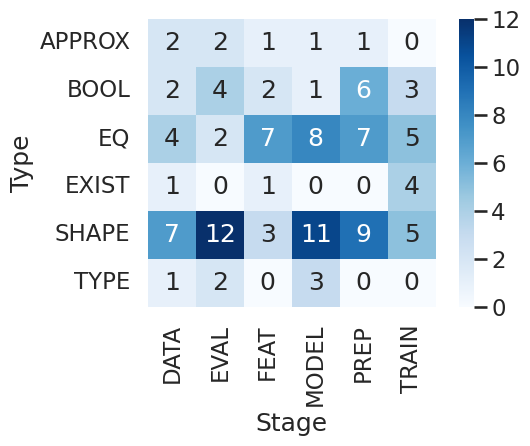

In [75]:
ax = sns.heatmap(
    freq,
    annot=True,
    cmap="Blues",
    square=True,
)
ax.get_figure().tight_layout()
ax.get_figure().savefig("report/distribution-stage-val.pdf")

## Type-EXP x Stage
- We conduct this test separately for GH and KG statements since source is associated with stage and intent (so it is a confounding variable).

In [90]:
d = data[(data["Intent"] == "EXP") & (data["Stage"] != "UNC")]
d.shape

(692, 11)

In [91]:
gh = d[d["source"] == "GH"]
kg = d[d["source"] == "KG"]

In [92]:
ghfreq, ghpct = counts(gh["Type"], gh["Stage"])
ghfreq

Stage,DATA,EVAL,FEAT,MODEL,PREP,TRAIN
Type,,,,,,
COMPUTE,7,34,11,3,10,17
INSPECT,31,30,16,8,24,12
STATS,5,4,0,1,10,0
STRUCT,11,4,8,4,9,4


In [93]:
ghpct

Stage,DATA,EVAL,FEAT,MODEL,PREP,TRAIN
Type,,,,,,
COMPUTE,0.085366,0.414634,0.134146,0.036585,0.121951,0.207317
INSPECT,0.256198,0.247934,0.132231,0.066116,0.198347,0.099174
STATS,0.250000,0.200000,0.000000,0.050000,0.500000,0.000000
STRUCT,0.275000,0.100000,0.200000,0.100000,0.225000,0.100000


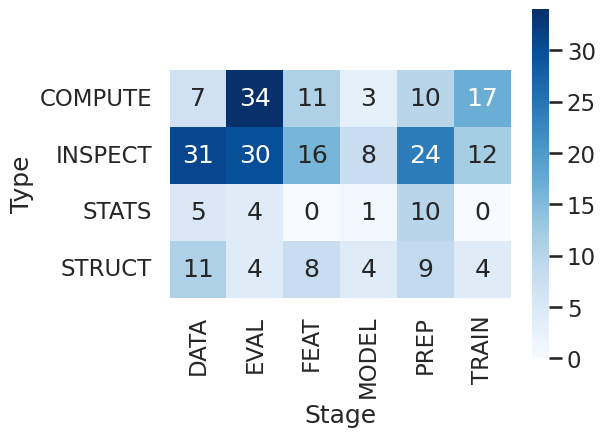

In [99]:
ax = sns.heatmap(
    ghfreq,
    annot=True,
    cmap="Blues",
    square=True,
)
ax.get_figure().tight_layout()
# ax.get_figure().savefig("report/distribution-stage-val.pdf")

In [94]:
chi2(ghfreq)

statistic: 44.65886814073984
pvalue: 8.666277561338842e-05
dof: 15
cramer's v: 0.23791145571702504
expected_freq:
[[16.8365019  22.4486692  10.91254753  4.98859316 16.52471483 10.28897338]
 [24.84410646 33.12547529 16.1026616   7.36121673 24.38403042 15.18250951]
 [ 4.10646388  5.47528517  2.66159696  1.21673004  4.03041825  2.5095057 ]
 [ 8.21292776 10.95057034  5.32319392  2.43346008  8.0608365   5.01901141]]
residuals:
Stage        DATA      EVAL      FEAT     MODEL      PREP     TRAIN
Type                                                               
COMPUTE -2.397258  2.438017  0.026473 -0.890342 -1.605072  2.092199
INSPECT  1.235035 -0.543044 -0.025583  0.235439 -0.077770 -0.816767
STATS    0.440939 -0.630482 -1.631440 -0.196482  2.973506 -1.584142
STRUCT   0.972522 -2.100400  1.160194  1.004221  0.330789 -0.454852


In [95]:
fisher(ghfreq)

statistic: 5.926609157789593e-20
pvalue: 0.0002
cramer's v: 0.23791145571702504


In [96]:
kgfreq, kgpct = counts(kg["Type"], kg["Stage"])
kgfreq

Stage,DATA,EVAL,FEAT,MODEL,PREP,TRAIN
Type,,,,,,
COMPUTE,0,28,14,0,42,19
INSPECT,23,43,23,1,91,1
STATS,0,4,4,0,50,0
STRUCT,6,1,10,0,69,0


In [97]:
chi2(kgfreq)

statistic: 126.57430418250469
pvalue: 9.939868053367337e-20
dof: 15
cramer's v: 0.3136053773425112
expected_freq:
[[  6.96270396  18.24708625  12.24475524   0.24009324  60.5034965
    4.8018648 ]
 [ 12.3030303   32.24242424  21.63636364   0.42424242 106.90909091
    8.48484848]
 [  3.92074592  10.27505828   6.8951049    0.13519814  34.06993007
    2.7039627 ]
 [  5.81351981  15.23543124  10.22377622   0.2004662   50.51748252
    4.00932401]]
residuals:
Stage        DATA      EVAL      FEAT     MODEL      PREP     TRAIN
Type                                                               
COMPUTE -2.638694  2.283167  0.501606 -0.489993 -2.378831  6.479274
INSPECT  3.049683  1.894526  0.293161  0.883960 -1.538644 -2.569573
STATS   -1.980087 -1.957607 -1.102539 -0.367693  2.729179 -1.644373
STRUCT   0.077342 -3.647063 -0.069986 -0.447735  2.600401 -2.002330


In [98]:
fisher(kgfreq)

statistic: 4.6319947049123625e-36
pvalue: 0.0001
cramer's v: 0.3136053773425112
